# 02.1 — Variance preconditioner M 텀 심층 분석

VP-SGLD 의 `M(x) = (I + β·Σ(x))^{-1}` 가 실제로 어떻게 작동하는지 확인.

각 class 에 대해 **4 runs**:

| N (chains) | ignore_variance |
|-----------|----------------|
| `N_LOW`  (10)  | False |
| `N_LOW`  (10)  | True  |
| `N_HIGH` (500) | False |
| `N_HIGH` (500) | True  |

비교 포인트:

1. **M 통계 (mean / min / max)**: step 에 따라 preconditioner 가 얼마나 identity 에서 벗어나는지
2. **Σ 통계 (mean / median / max)**: 앙상블 멤버 간 score disagreement
3. **drift vs noise**: `‖η·M·μ‖` vs `‖√(2ητM)·ξ‖`, 그리고 비율

시각화는 scatter/chain image 없음 — **scalar 시계열 plot 중심**.
저장: raw npz + 비교 PNG 전부 **로컬**.

## 0. 설정

In [8]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import os, sys, json, argparse, shlex, time, datetime as _dt
os.chdir('/home/work/JooKyung/TabEBM')
sys.path.insert(0, 'experiments'); sys.path.insert(0, 'src')
from pathlib import Path

import numpy as np, pandas as pd
import matplotlib.pyplot as plt

from tabebm.vp_sgld import vp_sgld_from_ensemble

# ======================================================================
#  ARGS — CLI-style
# ======================================================================
ARGS_STR = '''
    # --- target ensemble (생략 시 latest *_EBM 자동) ---
    # --ensemble-root experiments/ebms/20260415_210238_Subsample-Distance_EBM

    # --- 공통 ---
    --classes 0 1
    --n-low 10
    --n-high 500
    --n-steps 50
    --beta 1.0 --eta 0.05 --tau 1.0 --sigma-start 0.1
    --auto-beta
    --seed 0 --gpu 0
'''

parser = argparse.ArgumentParser(add_help=False)
parser.add_argument('--ensemble-root', type=Path, default=None)
parser.add_argument('--classes', type=int, nargs='+', default=[0, 1])
parser.add_argument('--n-low', type=int, default=10)
parser.add_argument('--n-high', type=int, default=500)
parser.add_argument('--n-steps', type=int, default=50)
parser.add_argument('--beta', type=float, default=1.0)
parser.add_argument('--eta', type=float, default=0.05)
parser.add_argument('--tau', type=float, default=1.0)
parser.add_argument('--sigma-start', type=float, default=0.1)
parser.add_argument('--auto-beta', action='store_true', default=False)
parser.add_argument('--no-auto-beta', dest='auto_beta', action='store_false')
parser.add_argument('--seed', type=int, default=0)
parser.add_argument('--gpu', type=int, default=0)

argv = []
for line in ARGS_STR.splitlines():
    line = line.split('#', 1)[0].strip()
    if line: argv.extend(shlex.split(line))
args = parser.parse_args(argv)

if args.ensemble_root is None:
    cand = sorted(p for p in Path('experiments/ebms').iterdir()
                   if p.is_dir() and p.name.endswith('_EBM'))
    args.ensemble_root = cand[-1]
    print(f'[auto] ensemble_root = {args.ensemble_root}')
assert (args.ensemble_root / 'c0' / 'meta.json').exists()

ts = _dt.datetime.now().strftime('%Y%m%d_%H%M%S')
OUT_DIR = args.ensemble_root / 'comparisons' / f'{ts}_M_term_analysis'
OUT_DIR.mkdir(parents=True, exist_ok=True)
(OUT_DIR / 'run_config.json').write_text(json.dumps(vars(args), indent=2, default=str))

print(f'ENSEMBLE_ROOT : {args.ensemble_root}')
print(f'OUT_DIR       : {OUT_DIR}')
print(f'runs          : {len(args.classes)} class × 2 (N={args.n_low},{args.n_high}) × 2 (ignore on/off) '
       f'= {len(args.classes)*4} total')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
[auto] ensemble_root = experiments/ebms/20260415_214026_Distance_EBM
ENSEMBLE_ROOT : experiments/ebms/20260415_214026_Distance_EBM
OUT_DIR       : experiments/ebms/20260415_214026_Distance_EBM/comparisons/20260416_161631_M_term_analysis
runs          : 2 class × 2 (N=10,500) × 2 (ignore on/off) = 8 total


## 1. SGLD 4 runs × class — per-step diag 전부 캡처

In [9]:
def run_one(class_dir, n_samples, ignore_variance, save_trajectory=True):
    '''Return (diag_mat (T, n_keys), keys, trajectory or None).'''
    res = vp_sgld_from_ensemble(
        class_dir,
        n_samples=n_samples, n_steps=args.n_steps,
        beta=args.beta, eta=args.eta, tau=args.tau,
        sigma_start=args.sigma_start,
        auto_beta=args.auto_beta, ignore_variance=ignore_variance,
        seed=args.seed, gpu=args.gpu,
        return_diagnostics=True, return_trajectory=save_trajectory,
    )
    if save_trajectory:
        _, diags, traj = res
        traj_np = traj.numpy().astype(np.float32)
    else:
        _, diags = res
        traj_np = None
    keys = [k for k in diags[0].keys() if isinstance(diags[0][k], (int, float))]
    arr = np.array([[d[k] for k in keys] for d in diags], dtype=np.float64)
    return arr, keys, traj_np

# results[c][(ig, N)] = (arr, keys)
results = {c: {} for c in args.classes}
t_total = time.time()
for c in args.classes:
    class_dir = args.ensemble_root / f'c{c}'
    print(f'\n=== class {c} ===')
    for N in [args.n_low, args.n_high]:
        for ig in [False, True]:
            t0 = time.time()
            # trajectory 항상 저장 (모든 N, 모든 ignore — 분석/M-vs-N scan 사용)
            arr, keys, traj_np = run_one(class_dir, n_samples=N,
                                           ignore_variance=ig,
                                           save_trajectory=True)
            results[c][(ig, N)] = (arr, keys, traj_np)
            traj_msg = f'  +traj{traj_np.shape}' if traj_np is not None else ''
            print(f'  N={N:<3d}  ignore_variance={ig}  ({time.time()-t0:.1f}s){traj_msg}')
print(f'\ntotal {time.time()-t_total:.1f}s')

# raw 저장: diag (전부) + trajectory (N_HIGH 만)
for c in args.classes:
    keys = results[c][(False, args.n_low)][1]
    save_kv = {'diag_cols': np.array(keys, dtype=object)}
    for (ig, N), (arr, _, traj_np) in results[c].items():
        save_kv[f'ignore{int(ig)}_N{N}'] = arr
        if traj_np is not None:
            save_kv[f'traj_ignore{int(ig)}_N{N}'] = traj_np
    np.savez_compressed(OUT_DIR / f'diag_raw_c{c}.npz', **save_kv)
    print(f'  saved: diag_raw_c{c}.npz  ({sum(1 for k in save_kv if k.startswith("traj_"))} trajectories)')


=== class 0 ===
  N=10   ignore_variance=False  (43.2s)  +traj(51, 10, 9)
  N=10   ignore_variance=True  (43.9s)  +traj(51, 10, 9)
  N=500  ignore_variance=False  (44.5s)  +traj(51, 500, 9)
  N=500  ignore_variance=True  (44.1s)  +traj(51, 500, 9)

=== class 1 ===
  N=10   ignore_variance=False  (43.6s)  +traj(51, 10, 9)
  N=10   ignore_variance=True  (43.2s)  +traj(51, 10, 9)
  N=500  ignore_variance=False  (43.5s)  +traj(51, 500, 9)
  N=500  ignore_variance=True  (43.3s)  +traj(51, 500, 9)

total 349.2s
  saved: diag_raw_c0.npz  (4 trajectories)
  saved: diag_raw_c1.npz  (4 trajectories)


## 2. M 전체 분포 — `M_mean ± [min, max]` 띠 로 step 별 표시

각 step 에서 전체 체인+차원 에 걸친 M 값이 **어느 범위에 퍼져있는지** (min 에서 max 까지) 를 따로 보여줌.
- `ignore_variance=True`: M=I 라 mean=min=max=1 (일직선)
- `ignore_variance=False`: M 이 1 보다 작아지고 (Σ>0 인 곳에서), min 이 내려가면 preconditioner 가 실제로 작동 중인 지점

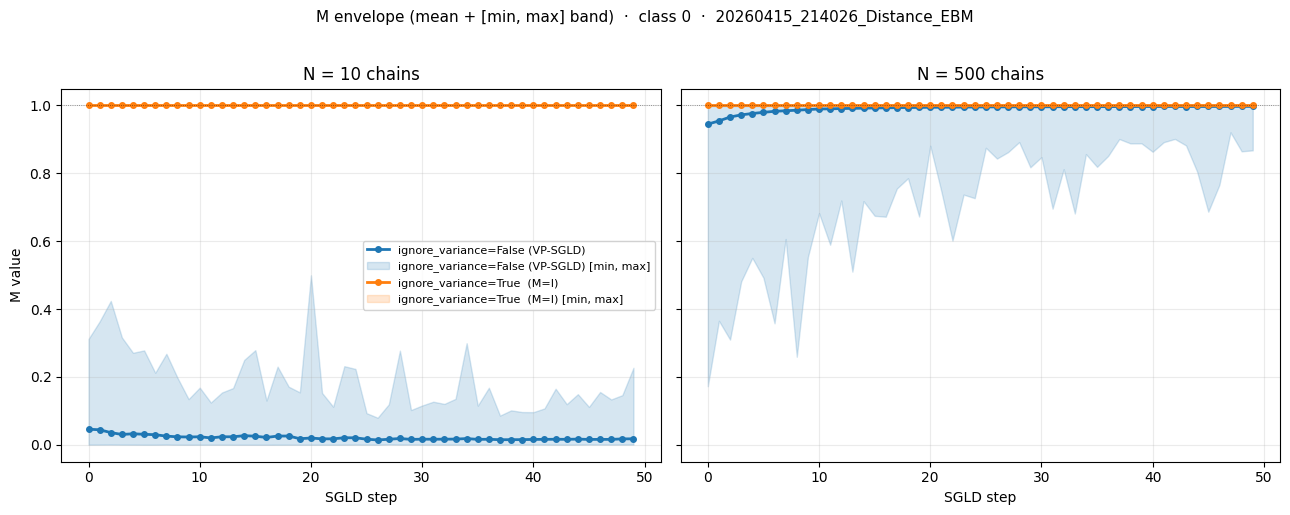

  saved: experiments/ebms/20260415_214026_Distance_EBM/comparisons/20260416_161631_M_term_analysis/M_envelope_c0.png


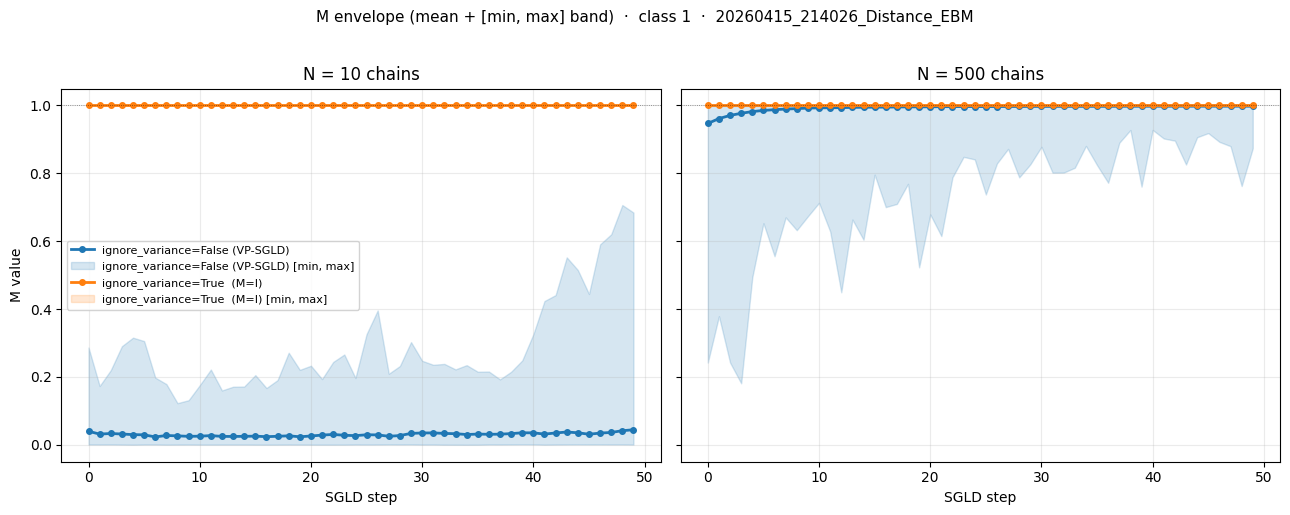

  saved: experiments/ebms/20260415_214026_Distance_EBM/comparisons/20260416_161631_M_term_analysis/M_envelope_c1.png


In [10]:
def plot_M_envelope(results_c, class_c, keys, out_dir):
    idx = {k: i for i, k in enumerate(keys)}
    T = next(iter(results_c.values()))[0].shape[0]
    steps = np.arange(T)
    colors = {False: 'tab:blue', True: 'tab:orange'}
    labels = {False: 'ignore_variance=False (VP-SGLD)',
               True:  'ignore_variance=True  (M=I)'}
    Ns = [args.n_low, args.n_high]
    fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
    for col_i, N in enumerate(Ns):
        ax = axes[col_i]
        for ig in [False, True]:
            arr = results_c[(ig, N)][0]
            m_mean = arr[:, idx['M_mean']]
            m_min  = arr[:, idx['M_min']]
            m_max  = arr[:, idx['M_max']]
            ax.plot(steps, m_mean, color=colors[ig], label=labels[ig],
                     linewidth=2, marker='o', markersize=4)
            ax.fill_between(steps, m_min, m_max, color=colors[ig], alpha=0.18,
                             label=f'{labels[ig]} [min, max]')
        ax.axhline(1.0, color='k', ls=':', lw=0.6, alpha=0.5)
        ax.set_xlabel('SGLD step'); ax.set_title(f'N = {N} chains')
        ax.grid(alpha=0.25)
        if col_i == 0:
            ax.set_ylabel('M value')
            ax.legend(fontsize=8, loc='best', framealpha=0.85)
    fig.suptitle(
        f'M envelope (mean + [min, max] band)  ·  class {class_c}  ·  '
        f'{args.ensemble_root.name}', fontsize=11, y=1.02,
    )
    plt.tight_layout()
    p = out_dir / f'M_envelope_c{class_c}.png'
    fig.savefig(p, dpi=140, bbox_inches='tight')
    plt.show()
    print(f'  saved: {p}')

for c in args.classes:
    keys = results[c][(False, args.n_low)][1]
    plot_M_envelope(results[c], c, keys, OUT_DIR)

## 3. Full dashboard — Σ / drift / noise / ratio 합쳐서

M 주변의 모든 텀을 한 figure 에. 각 class 당:
- row 1: `var_median`, `var_mean`, `var_max` (Σ 분포)
- row 2: `drift_norm`, `noise_norm`, `drift_over_noise` (업데이트 텀 크기)
- 각 subplot: `ignore=False` vs `True` 색 구분, N=low vs N=high line-style 구분

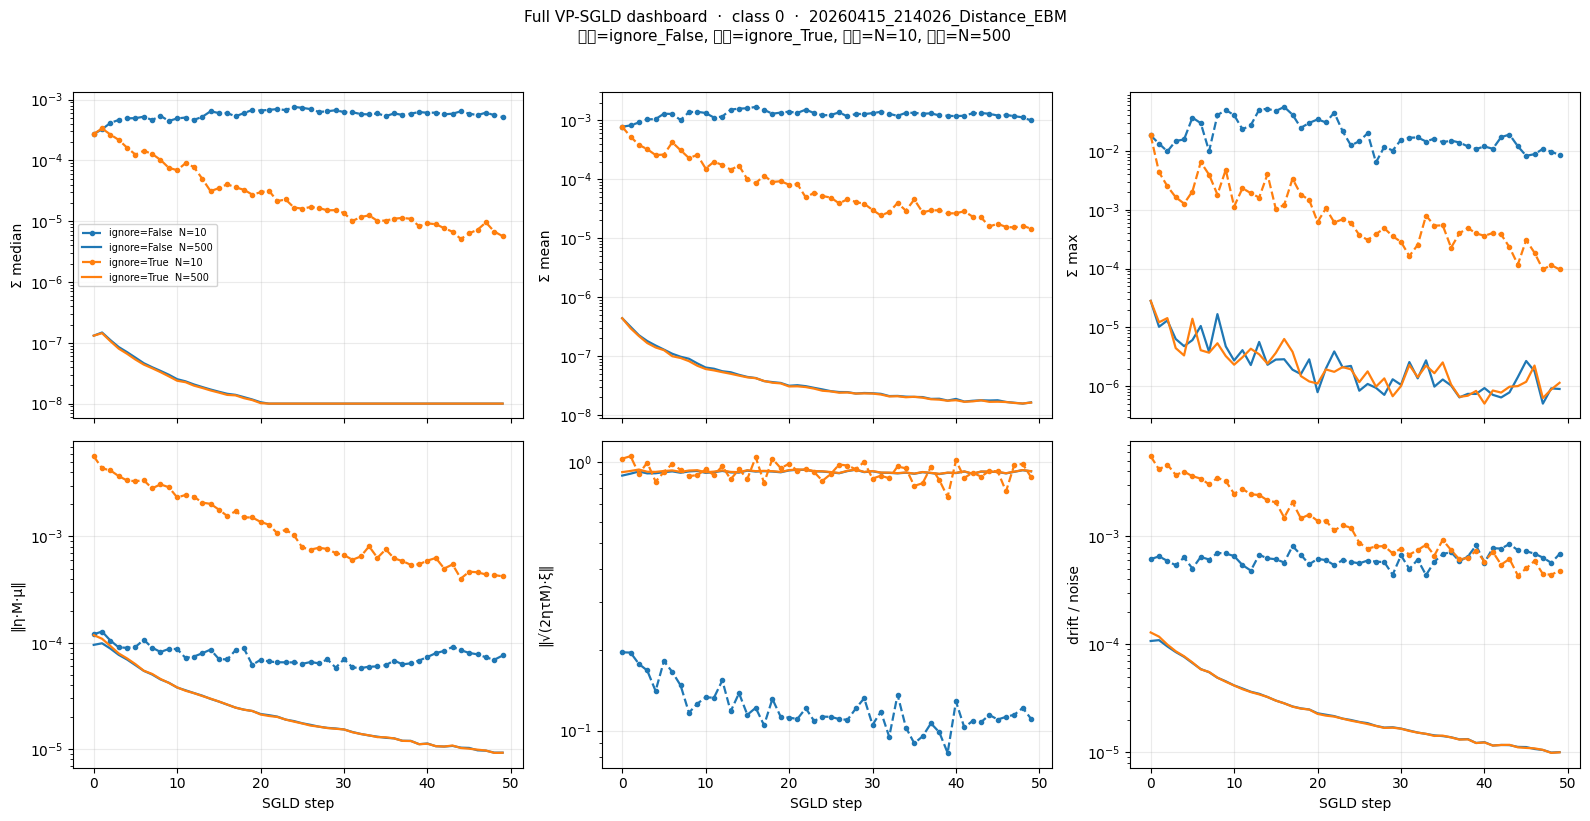

  saved: experiments/ebms/20260415_214026_Distance_EBM/comparisons/20260416_161631_M_term_analysis/full_dashboard_c0.png


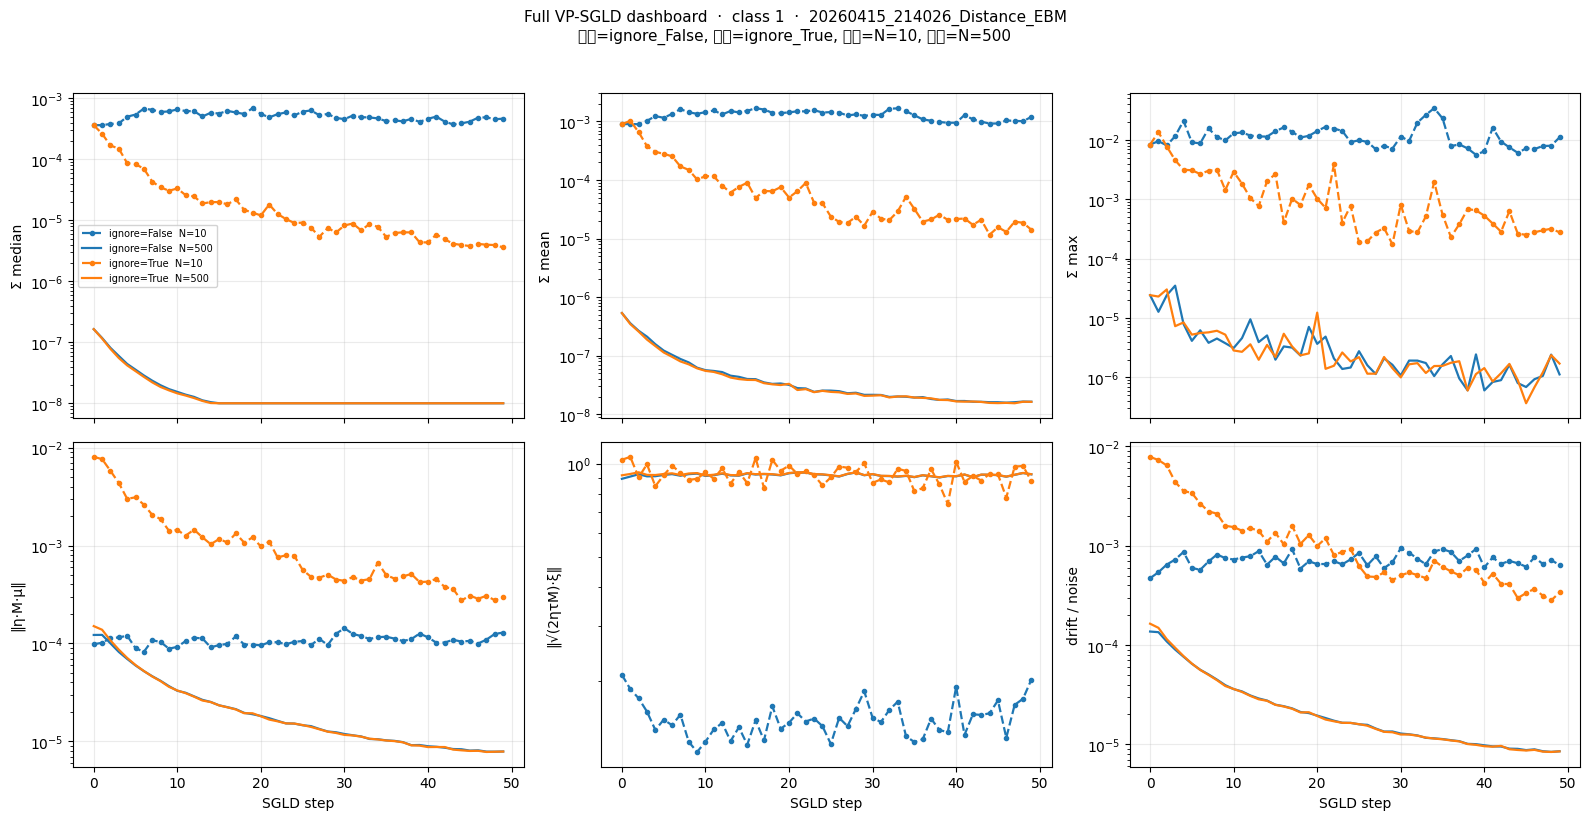

  saved: experiments/ebms/20260415_214026_Distance_EBM/comparisons/20260416_161631_M_term_analysis/full_dashboard_c1.png


In [11]:
def plot_full_dashboard(results_c, class_c, keys, out_dir):
    idx = {k: i for i, k in enumerate(keys)}
    T = next(iter(results_c.values()))[0].shape[0]
    steps = np.arange(T)

    rows = [
        [('var_median', 'Σ median'), ('var_mean', 'Σ mean'), ('var_max', 'Σ max')],
        [('drift_norm', '‖η·M·μ‖'), ('noise_norm', '‖√(2ητM)·ξ‖'),
          ('drift_over_noise', 'drift / noise')],
    ]
    colors = {False: 'tab:blue', True: 'tab:orange'}
    linestyles = {args.n_low: '--', args.n_high: '-'}

    fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharex=True)
    for r, row_keys in enumerate(rows):
        for c_i, (key, ylabel) in enumerate(row_keys):
            ax = axes[r, c_i]
            for ig in [False, True]:
                for N in [args.n_low, args.n_high]:
                    arr = results_c[(ig, N)][0]
                    y = arr[:, idx[key]]
                    label = f'ignore={ig}  N={N}'
                    ax.plot(steps, y, color=colors[ig], linestyle=linestyles[N],
                             label=label, linewidth=1.6,
                             marker='o' if N == args.n_low else None, markersize=3)
            ax.set_ylabel(ylabel); ax.grid(alpha=0.25)
            if key in ('var_median', 'var_mean', 'var_max',
                        'drift_norm', 'noise_norm', 'drift_over_noise'):
                try:
                    ax.set_yscale('log')
                except Exception:
                    pass
            if r == 1:
                ax.set_xlabel('SGLD step')
            if r == 0 and c_i == 0:
                ax.legend(fontsize=7, loc='best', framealpha=0.85)
    fig.suptitle(
        f'Full VP-SGLD dashboard  ·  class {class_c}  ·  {args.ensemble_root.name}\n'
        f'파랑=ignore_False, 주황=ignore_True, 점선=N={args.n_low}, 실선=N={args.n_high}',
        fontsize=11, y=1.02,
    )
    plt.tight_layout()
    p = out_dir / f'full_dashboard_c{class_c}.png'
    fig.savefig(p, dpi=140, bbox_inches='tight')
    plt.show()
    print(f'  saved: {p}')

for c in args.classes:
    keys = results[c][(False, args.n_low)][1]
    plot_full_dashboard(results[c], c, keys, OUT_DIR)

## 4. 요약 표 — 시작 vs 끝 step 비교

In [12]:
rows = []
for c in args.classes:
    keys = results[c][(False, args.n_low)][1]
    idx = {k: i for i, k in enumerate(keys)}
    for N in [args.n_low, args.n_high]:
        for ig in [False, True]:
            arr = results[c][(ig, N)][0]
            r0, rT = arr[0], arr[-1]
            rows.append({
                'class': c, 'N': N, 'ignore_variance': ig,
                'M_mean_init':    float(r0[idx['M_mean']]),
                'M_mean_final':   float(rT[idx['M_mean']]),
                'M_min_final':    float(rT[idx['M_min']]),
                'M_max_final':    float(rT[idx['M_max']]),
                'var_median_T':   float(rT[idx['var_median']]),
                'var_max_T':      float(rT[idx['var_max']]),
                'drift/noise_T':  float(rT[idx['drift_over_noise']]),
            })
df = pd.DataFrame(rows)
df.to_csv(OUT_DIR / 'summary_M_analysis.csv', index=False)
print(f'  saved: {OUT_DIR / "summary_M_analysis.csv"}')
df

  saved: experiments/ebms/20260415_214026_Distance_EBM/comparisons/20260416_161631_M_term_analysis/summary_M_analysis.csv


,class,N,ignore_variance,M_mean_init,M_mean_final,M_min_final,M_max_final,var_median_T,var_max_T,drift/noise_T
0,0,10,False,0.045885,0.017661,0.000694,0.226905,5.167865e-04,8.490268e-03,0.000686
1,0,10,True,1.000000,1.000000,1.000000,1.000000,5.696207e-06,9.661563e-05,0.000481
2,0,500,False,0.945011,0.997249,0.867755,0.998306,1.000000e-08,8.983041e-07,0.000010
3,0,500,True,1.000000,1.000000,1.000000,1.000000,1.000000e-08,1.143647e-06,0.000010
4,1,10,False,0.040018,0.044441,0.000703,0.684513,4.632611e-04,1.104828e-02,0.000639
5,1,10,True,1.000000,1.000000,1.000000,1.000000,3.591011e-06,2.779615e-04,0.000338
6,1,500,False,0.947078,0.997919,0.873753,0.998715,1.000000e-08,1.122547e-06,0.000009
7,1,500,True,1.000000,1.000000,1.000000,1.000000,1.000000e-08,1.709209e-06,0.000009


## 5. M  vs  N 스캔 — `N` 을 0 → 500 까지 바꾸며 M 추적

여러 N 값으로 각각 SGLD 돌리고 `M_mean` (초기 step 0 / 최종 step T) 을 그래프로.
x=N (log scale), y=M. ignore_variance on/off 둘 다 플롯.

**주의**: N 마다 SGLD 한 번씩이라 시간 걸림. 기본값 T=20 로 빠르게 (원래 T=50 은 너무 느림).
N list 는 `N_SWEEP` 에서 조정.

In [13]:
from tabebm.vp_sgld import ensemble_score_var_fn, compute_beta_scale
import torch

# --- 설정 ----------------------------------------------------------------
# N_SWEEP: N 을 얼마나 촘촘히 볼지. trajectory subset 재사용이라 cost 저렴.
# 아래 중 하나 골라 쓰거나 직접 편집.
#
# (a) sparse — 8 points 대충 흐름만                       (default 이전)
#     N_SWEEP = [2, 5, 10, 20, 50, 100, 200, 500]
# (b) medium — log spaced ~30 points
#     N_SWEEP = sorted(set(int(round(n)) for n in np.logspace(np.log10(2), np.log10(500), 30)))
# (c) dense — 저-N 구간 전부 정수 + log 상한까지 (~60 points, 현재 default)
N_SWEEP = sorted(set(
    list(range(2, 21)) +                                  # 2..20 전부
    [int(round(n)) for n in np.logspace(np.log10(21),     # 21..500 log-spaced 40 점
                                          np.log10(500), 40)]
))
# (d) very-dense — 2..500 모든 정수 (499 points, 평가 ~10 분)
#     N_SWEEP = list(range(2, 501))

EVAL_AT_STEPS  = [0, args.n_steps]                    # M 평가 step (init=0, final=T)
CLASSES_NSCAN  = args.classes
# -------------------------------------------------------------------------
print(f'N_SWEEP: {len(N_SWEEP)} points  ({N_SWEEP[:5]} ... {N_SWEEP[-3:]})')
# cell 4 에서 N=N_HIGH (=500) 의 trajectory 가 results[c][(ig, N_HIGH)][2] 에 있음.
# subset M 은 score_var_fn 한 번 호출이면 끝. SGLD 재실행 X.

scan = {c: {} for c in CLASSES_NSCAN}
t_total = time.time()
for c in CLASSES_NSCAN:
    class_dir = args.ensemble_root / f'c{c}'
    score_var_fn = ensemble_score_var_fn(class_dir, gpu=args.gpu)
    real_tensor = torch.from_numpy(np.load(class_dir / 'class_data.npz')['X_class']) \
                       .float().to(f'cuda:{args.gpu}')
    if args.auto_beta:
        beta_eff = args.beta * compute_beta_scale(score_var_fn, real_tensor)
    else:
        beta_eff = args.beta
    print(f'\n=== class {c} ===   beta_eff={beta_eff:.3e}')

    for ig in [False, True]:
        traj_np = results[c][(ig, args.n_high)][2]
        if traj_np is None:
            print(f'  [skip] ignore={ig}: trajectory 없음 — cell 4 다시 실행 필요')
            continue
        scan[c][ig] = {'Ns': list(N_SWEEP),
                        **{f'M_step{s}': [] for s in EVAL_AT_STEPS}}
        for N in N_SWEEP:
            for step_t in EVAL_AT_STEPS:
                step_clip = min(step_t, traj_np.shape[0] - 1)
                x_subset = torch.from_numpy(traj_np[step_clip, :N, :]).float() \
                                .to(f'cuda:{args.gpu}')
                _, var = score_var_fn(x_subset)
                if ig:
                    M = torch.ones_like(var)
                else:
                    M = 1.0 / (1.0 + beta_eff * var.clamp_min(1e-8))
                scan[c][ig][f'M_step{step_t}'].append(float(M.mean().item()))
            print(f'  N={N:<4d}  ignore={ig}  '
                   f"M_init={scan[c][ig][f'M_step{EVAL_AT_STEPS[0]}'][-1]:.4f}  "
                   f"M_final={scan[c][ig][f'M_step{EVAL_AT_STEPS[-1]}'][-1]:.4f}")

print(f'\ntotal {time.time()-t_total:.1f}s   (저장된 trajectory 의 subset 만 평가, SGLD 재실행 없음)')

# CSV 저장
scan_rows = []
for c in CLASSES_NSCAN:
    for ig in [False, True]:
        if ig not in scan[c]: continue
        for i, N in enumerate(N_SWEEP):
            row = {'class': c, 'N': N, 'ignore_variance': ig}
            for s in EVAL_AT_STEPS:
                row[f'M_step{s}'] = scan[c][ig][f'M_step{s}'][i]
            scan_rows.append(row)
scan_df = pd.DataFrame(scan_rows)
scan_df.to_csv(OUT_DIR / 'M_vs_N_scan.csv', index=False)
print(f'  saved: {OUT_DIR / "M_vs_N_scan.csv"}')
scan_df


N_SWEEP: 59 points  ([2, 3, 4, 5, 6] ... [425, 461, 500])

=== class 0 ===   beta_eff=1.697e+05
  N=2     ignore=False  M_init=0.0005  M_final=0.0957
  N=3     ignore=False  M_init=0.0043  M_final=0.1754
  N=4     ignore=False  M_init=0.0075  M_final=0.3315
  N=5     ignore=False  M_init=0.0109  M_final=0.3890
  N=6     ignore=False  M_init=0.0143  M_final=0.3936
  N=7     ignore=False  M_init=0.0221  M_final=0.4012
  N=8     ignore=False  M_init=0.0320  M_final=0.4376
  N=9     ignore=False  M_init=0.0394  M_final=0.4850
  N=10    ignore=False  M_init=0.0459  M_final=0.4866
  N=11    ignore=False  M_init=0.0516  M_final=0.5088
  N=12    ignore=False  M_init=0.0610  M_final=0.5502
  N=13    ignore=False  M_init=0.0676  M_final=0.5605
  N=14    ignore=False  M_init=0.0761  M_final=0.5821
  N=15    ignore=False  M_init=0.0888  M_final=0.6011
  N=16    ignore=False  M_init=0.0958  M_final=0.6180
  N=17    ignore=False  M_init=0.1027  M_final=0.6380
  N=18    ignore=False  M_init=0.1122  M

,class,N,ignore_variance,M_step0,M_step50
0,0,2,False,0.000526,0.095737
1,0,3,False,0.004339,0.175370
2,0,4,False,0.007534,0.331532
3,0,5,False,0.010865,0.388992
4,0,6,False,0.014293,0.393558
...,...,...,...,...,...
231,1,361,True,1.000000,1.000000
232,1,392,True,1.000000,1.000000
233,1,425,True,1.000000,1.000000
234,1,461,True,1.000000,1.000000


### 5-b. M vs N plot

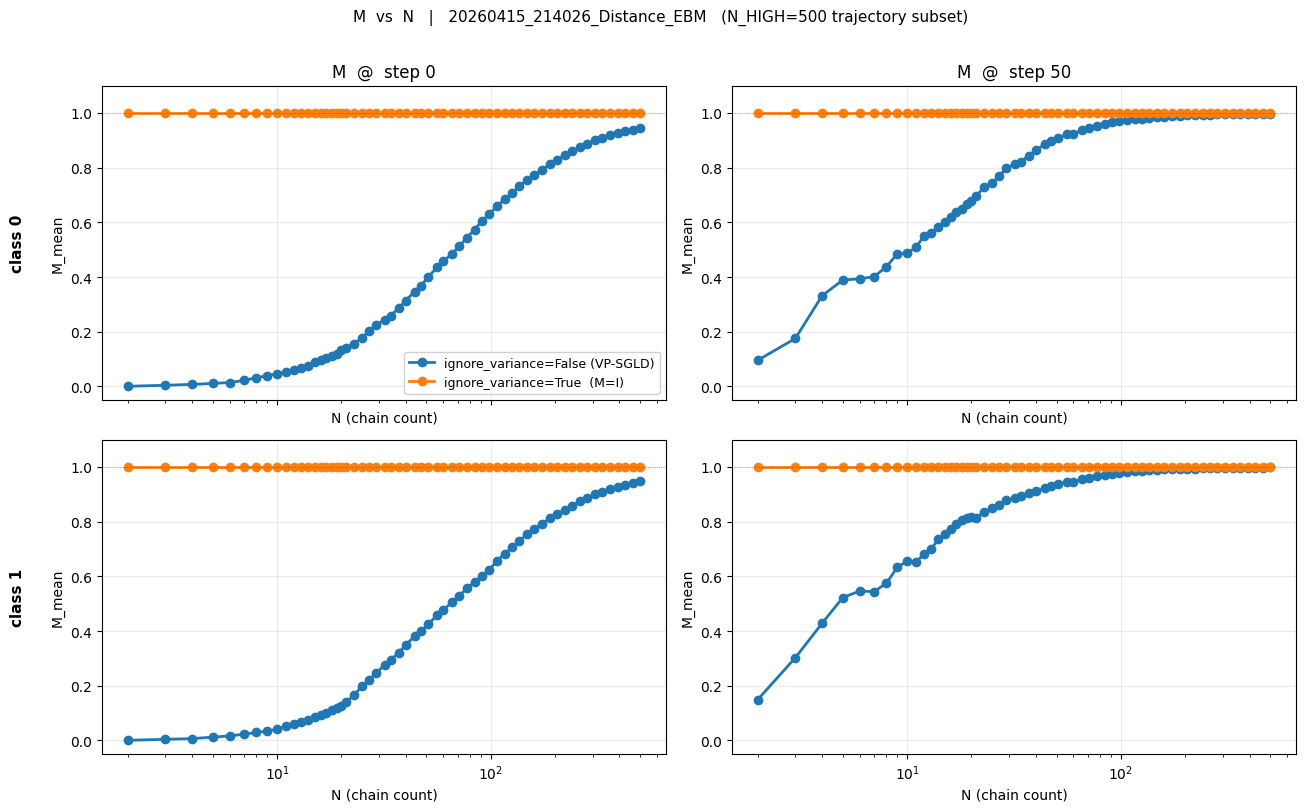

  saved: experiments/ebms/20260415_214026_Distance_EBM/comparisons/20260416_161631_M_term_analysis/M_vs_N_scan.png


In [14]:
colors = {False: 'tab:blue', True: 'tab:orange'}
labels = {False: 'ignore_variance=False (VP-SGLD)',
           True:  'ignore_variance=True  (M=I)'}

n_steps_to_plot = len(EVAL_AT_STEPS)
fig, axes = plt.subplots(len(CLASSES_NSCAN), n_steps_to_plot,
                          figsize=(6.5*n_steps_to_plot, 4*len(CLASSES_NSCAN)),
                          sharex=True, squeeze=False)
for row, c in enumerate(CLASSES_NSCAN):
    for col, step_t in enumerate(EVAL_AT_STEPS):
        ax = axes[row, col]
        for ig in [False, True]:
            if ig not in scan[c]: continue
            Ns = scan[c][ig]['Ns']
            ys = scan[c][ig][f'M_step{step_t}']
            ax.plot(Ns, ys, color=colors[ig], label=labels[ig],
                     linewidth=2, marker='o', markersize=6)
        ax.set_xscale('log')
        ax.set_xlabel('N (chain count)')
        ax.set_ylabel('M_mean')
        ax.axhline(1.0, color='k', ls=':', lw=0.6, alpha=0.4)
        ax.set_ylim(-0.05, 1.1)
        ax.grid(alpha=0.25)
        if row == 0:
            ax.set_title(f'M  @  step {step_t}')
        if col == 0:
            ax.annotate(f'class {c}', xy=(-0.15, 0.5), xycoords='axes fraction',
                         fontsize=11, fontweight='bold',
                         ha='center', va='center', rotation=90)
        if row == 0 and col == 0:
            ax.legend(fontsize=9, loc='lower right', framealpha=0.9)

fig.suptitle(f'M  vs  N   |   {args.ensemble_root.name}   '
              f'(N_HIGH={args.n_high} trajectory subset)',
              fontsize=11, y=1.01)
plt.tight_layout()
p = OUT_DIR / 'M_vs_N_scan.png'
fig.savefig(p, dpi=140, bbox_inches='tight')
plt.show()
print(f'  saved: {p}')


## 6. 저장 디렉토리 요약

In [15]:
print(f'=== {OUT_DIR} ===')
for p in sorted(OUT_DIR.iterdir()):
    print(f'  {p.name:<32}  {p.stat().st_size:>10} bytes')

=== experiments/ebms/20260415_214026_Distance_EBM/comparisons/20260416_161631_M_term_analysis ===
  M_envelope_c0.png                     118931 bytes
  M_envelope_c1.png                     115045 bytes
  M_vs_N_scan.csv                         8342 bytes
  M_vs_N_scan.png                       117812 bytes
  diag_raw_c0.npz                      1748779 bytes
  diag_raw_c1.npz                      1748684 bytes
  full_dashboard_c0.png                 266485 bytes
  full_dashboard_c1.png                 270286 bytes
  run_config.json                          264 bytes
  summary_M_analysis.csv                  1097 bytes
